In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv('../../data/eeg_reports.csv', engine='python', on_bad_lines='skip')
print(f'Total rows: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
print()
print(df['ServiceName'].value_counts())

Total rows: 49,846
Columns: ['SiteID', 'BDSPPatientID', 'SessionID', 'ServiceName', 'StartTime', 'EndTime', 'ReportPath', 'Year', 'ReportText', 'ReportTextRedacted']

ServiceName
LTM         26722
Routine     15712
EMU          6800
Faulkner      542
OR             51
Fish           19
Name: count, dtype: int64


In [3]:
KEEP_SERVICES = ['Routine', 'LTM', 'EMU']
df_main = df[df['ServiceName'].isin(KEEP_SERVICES)].copy()
print(f'Rows after filtering to Routine/LTM/EMU: {len(df_main):,}')
print(f'Dropped: {len(df) - len(df_main):,} rows (Faulkner, OR, Fish)')
print()
print(df_main['ServiceName'].value_counts())

Rows after filtering to Routine/LTM/EMU: 49,234
Dropped: 612 rows (Faulkner, OR, Fish)

ServiceName
LTM        26722
Routine    15712
EMU         6800
Name: count, dtype: int64


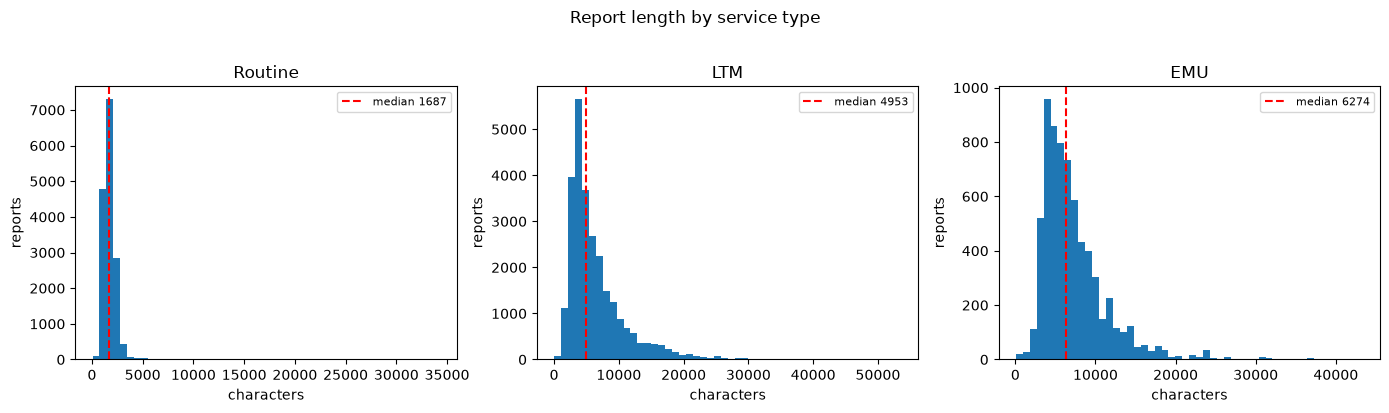

               count    mean     std   min     25%     50%     75%      max
ServiceName                                                                
EMU           6800.0  7250.0  4091.0  60.0  4440.0  6274.0  8818.0  43350.0
LTM          26722.0  6516.0  4758.0  16.0  3536.0  4953.0  7912.0  53559.0
Routine      15712.0  1785.0  1010.0  54.0  1340.0  1687.0  2062.0  34237.0


In [4]:
df_main['report_len'] = df_main['ReportTextRedacted'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, svc in zip(axes, KEEP_SERVICES):
    subset = df_main[df_main['ServiceName'] == svc]['report_len']
    ax.hist(subset, bins=50, edgecolor='none')
    ax.set_title(svc)
    ax.set_xlabel('characters')
    ax.set_ylabel('reports')
    ax.axvline(subset.median(), color='red', linestyle='--', label=f'median {subset.median():.0f}')
    ax.legend(fontsize=8)
plt.suptitle('Report length by service type', y=1.02)
plt.tight_layout()
plt.show()

print(df_main.groupby('ServiceName')['report_len'].describe().round(0))

In [5]:
for svc in KEEP_SERVICES:
    sample = df_main[df_main['ServiceName'] == svc].iloc[0]['ReportTextRedacted']
    print(f'{"="*60}')
    print(f'SERVICE: {svc}')
    print(f'{"="*60}')
    print(sample[:3000])
    print()

SERVICE: Routine
This is an abnormal EEG in the drowsy and sedated states due 
to:
1. Generalized irregular slowing at 3-6 Hz
2. Focal irregular delta slowing over the right frontal temporal region at 
1-2 Hz
3. Frequent slow waves over he frontal regions, occasionally repetitive at 
about .5-1 Hz and of higher amplitude on the right
4. Higher amplitude of faster frequencies over the right fronto temporal 
region consistent with a [REDACTED] of the skull. 
 
COMPARISON: no previous EEG available for comparison 
 
INDICATION: [REDACTED] is a [REDACTED] y.o. male with AAA s/p repair, mechanical AVR on 
anticoagulation, COPD, admitted from nursing home with AMS, shock, and 
metabolic derangements, intubated in [REDACTED]. [REDACTED] with evidence of new right 
craniotomy since [DATE], unclear reason why. 
 
PERTINENT MEDICATIONS: Dexmedetomidine
 
METHOD: Standard [REDACTED]-[REDACTED] electrode placement, single lead EKG, continuous 
video. 
 
DETAIL: The resting background showed genera

In [5]:
HEADER_RE = re.compile(r'^[A-Z][A-Z\s/]{4,}:?\s*$')

for svc in KEEP_SERVICES:
    subset = df_main[df_main['ServiceName'] == svc]['ReportTextRedacted']
    header_counts = {}
    for text in subset:
        seen = set()
        for line in text.split('\n'):
            line = line.strip()
            if HEADER_RE.match(line) and line not in seen:
                header_counts[line] = header_counts.get(line, 0) + 1
                seen.add(line)
    print(f'\n=== {svc} (n={len(subset):,}) ===')
    for h, count in sorted(header_counts.items(), key=lambda x: -x[1])[:20]:
        pct = 100 * count / len(subset)
        print(f'  {pct:5.1f}%  {h}')


=== Routine (n=15,712) ===
   35.8%  DETAILS:
   32.5%  TECHNICAL SUMMARY:
   15.7%  DETAIL:
    2.9%  COMPARISON:
    2.2%  PERTINENT MEDICATIONS:
    2.0%  INDICATION:
    1.9%  METHODOLOGY:
    1.8%  ROUTINE EEG REPORT
    1.8%  IMPRESSION:
    1.6%  METHOD:
    0.9%  EPILEPTIFORM ABNORMALITIES:
    0.9%  PROVOKING MANEUVERS:
    0.9%  METADATA:
    0.8%  DETAIL
    0.5%  CLINICAL INDICATION:
    0.4%  NOTABLE NORMAL VARIANT PATTERNS:
    0.4%  IMPRESSION / SUMMARY:
    0.4%  ROUTINE EEG
    0.3%  EPOCH
    0.2%  HISTORY/REASON FOR MONITORING:

=== LTM (n=26,722) ===
   44.7%  METHODOLOGY:
   27.9%  DETAIL
   19.9%  EPOCH
   19.2%  METADATA:
   10.9%  IMPRESSION / SUMMARY:
    5.9%  EEG REPORT
    5.7%  LIST OF FINDINGS TO DATE:
    4.3%  BACKGROUND:
    3.0%  HISTORY/REASON FOR MONITORING:
    2.5%  EVENTS:
    2.2%  EPOCH IMPRESSION:
    1.6%  SEIZURES:
    1.5%  NOTES ON THE PROGNOSTIC SIGNIFICANCE OF ABNORMAL EEG PATTERNS SEEN IN
    1.5%  PERIODIC OR RHYTHMIC PATTERNS:
    1.4

In [6]:
ltm = df_main[df_main['ServiceName'] == 'LTM']['ReportTextRedacted']

epoch_counts = ltm.apply(lambda t: len(re.findall(r'\bEPOCH\b', t)))
print('LTM epoch counts per report:')
print(epoch_counts.value_counts().sort_index().head(20))
print()
print(f'Reports with 0 epochs: {(epoch_counts == 0).sum():,}')
print(f'Reports with 1 epoch:  {(epoch_counts == 1).sum():,}')
print(f'Reports with 2+ epochs: {(epoch_counts >= 2).sum():,}')

LTM epoch counts per report:
ReportTextRedacted
0     12705
1      2825
2      2113
3       991
4      2166
5       577
6      1095
7       334
8       811
9       195
10      485
11      135
12      372
13      182
14      255
15       91
16      196
17       50
18      133
19       52
Name: count, dtype: int64

Reports with 0 epochs: 12,705
Reports with 1 epoch:  2,825
Reports with 2+ epochs: 11,192


In [7]:
# The impression/summary is likely the most extractable finding block
IMPRESSION_RE = re.compile(r'(IMPRESSION|SUMMARY|IMPRESSION\s*/\s*SUMMARY)', re.IGNORECASE)

for svc in KEEP_SERVICES:
    subset = df_main[df_main['ServiceName'] == svc]['ReportTextRedacted']
    has_impression = subset.apply(lambda t: bool(IMPRESSION_RE.search(t)))
    print(f'{svc}: {has_impression.sum():,} / {len(subset):,} have IMPRESSION/SUMMARY ({100*has_impression.mean():.1f}%)')

Routine: 7,657 / 15,712 have IMPRESSION/SUMMARY (48.7%)
LTM: 22,417 / 26,722 have IMPRESSION/SUMMARY (83.9%)
EMU: 4,634 / 6,800 have IMPRESSION/SUMMARY (68.1%)


In [7]:
def extract_impression(text):
    # handle IMPRESSION:, IMPRESSION / SUMMARY:, IMPRESSION/SUMMARY:
    match = re.search(
        r'IMPRESSION(?:\s*/\s*SUMMARY)?\s*:\s*(.*?)(?=\n[A-Z][A-Z\s/]{4,}:|\Z)',
        text, re.DOTALL
    )
    if match:
        block = match.group(1).strip()
        # drop blank lines and stray 'None' lines
        lines = [l.strip() for l in block.split('\n') if l.strip() and l.strip() != 'None']
        return '\n'.join(lines)
    return None

for svc in KEEP_SERVICES:
    subset = df_main[df_main['ServiceName'] == svc]
    hits = subset[subset['ReportTextRedacted'].str.contains('IMPRESSION', na=False)]
    if len(hits) == 0:
        print(f'{svc}: no hits')
        continue
    sample_text = hits.iloc[0]['ReportTextRedacted']
    result = extract_impression(sample_text)
    print(f'=== {svc} IMPRESSION ===')
    print(result[:600] if result else 'NOT FOUND')
    print()

=== Routine IMPRESSION ===
Normal EEG. No epileptiform activity was seen.

=== LTM IMPRESSION ===
Abnormal EEG in the critically ill state due to:
1. Diffuse polymorphic delta slowing of the background
2. Frequent multifocal but predominantly left hemispheric epileptiform
discharges
3. Frequent multifocal but [REDACTED] predominant independent sharp
[REDACTED]
Time course of findings is described in the detail. [REDACTED] are reported
from most recent to most remote, top to bottom.
[REDACTED]------------------------------------------------------[REDACTED]

=== EMU IMPRESSION ===
Abnormal [REDACTED] due to:
1) Frequent spike and spike-and-wave discharges over the left frontotemporal region at F7/T3/T5/T1, rarely with minimal spread to [REDACTED]/F3/P3. There were also occasional spike and sharp-wave discharges over the right frontotemporal region at F8/T4/T6/T2. Overall L/R ratio: 90/10.
2) Occasional spike and sharp-wave discharges over the right frontotemporal region at F8/T4/T6/T2 le

In [8]:
# what does a no-impression Routine report look like?
no_imp = df_main[
    (df_main['ServiceName'] == 'Routine') &
    (~df_main['ReportTextRedacted'].str.contains('IMPRESSION', na=False))
].iloc[0]['ReportTextRedacted']

print('=== Routine without IMPRESSION ===')
print(no_imp[:2000])

=== Routine without IMPRESSION ===
This is an abnormal EEG in the drowsy and sedated states due 
to:
1. Generalized irregular slowing at 3-6 Hz
2. Focal irregular delta slowing over the right frontal temporal region at 
1-2 Hz
3. Frequent slow waves over he frontal regions, occasionally repetitive at 
about .5-1 Hz and of higher amplitude on the right
4. Higher amplitude of faster frequencies over the right fronto temporal 
region consistent with a [REDACTED] of the skull. 
 
COMPARISON: no previous EEG available for comparison 
 
INDICATION: [REDACTED] is a [REDACTED] y.o. male with AAA s/p repair, mechanical AVR on 
anticoagulation, COPD, admitted from nursing home with AMS, shock, and 
metabolic derangements, intubated in [REDACTED]. [REDACTED] with evidence of new right 
craniotomy since [DATE], unclear reason why. 
 
PERTINENT MEDICATIONS: Dexmedetomidine
 
METHOD: Standard [REDACTED]-[REDACTED] electrode placement, single lead EKG, continuous 
video. 
 
DETAIL: The resting backgr

In [9]:
BOILERPLATE_PATTERNS = [
    r'\[REDACTED\]-+\[REDACTED\]',       # separator lines
    r'METHODOLOGY:.*?(?=\n[A-Z]{4}|\Z)', # methodology block
    r'METADATA:.*?(?=\n[A-Z]{4}|\Z)',    # metadata block
    r'ABBREVIATIONS.*?(?=\n[A-Z]{4}|\Z)',# abbreviations block
    r'I \(\[REDACTED\]\) have.*?\.',      # attending attestation line
    r'\[REDACTED\].*?MD\.?$',            # signature lines
]

for svc in KEEP_SERVICES:
    sample = df_main[df_main['ServiceName'] == svc].iloc[0]['ReportTextRedacted']
    cleaned = sample
    for pat in BOILERPLATE_PATTERNS:
        cleaned = re.sub(pat, '', cleaned, flags=re.DOTALL | re.MULTILINE)
    cleaned = re.sub(r'\n{3,}', '\n\n', cleaned).strip()
    print(f'=== {svc} after boilerplate removal ===')
    print(f'original: {len(sample)} chars → cleaned: {len(cleaned)} chars')
    print(cleaned[:1000])
    print()

=== Routine after boilerplate removal ===
original: 2018 chars → cleaned: 425 chars
This is an abnormal EEG in the drowsy and sedated states due 
to:
1. Generalized irregular slowing at 3-6 Hz
2. Focal irregular delta slowing over the right frontal temporal region at 
1-2 Hz
3. Frequent slow waves over he frontal regions, occasionally repetitive at 
about .5-1 Hz and of higher amplitude on the right
4. Higher amplitude of faster frequencies over the right fronto temporal 
region consistent with a 
[DATE]

=== LTM after boilerplate removal ===
original: 2977 chars → cleaned: 235 chars
IMPRESSION / SUMMARY: Abnormal EEG in the critically ill state due to:
1. Diffuse polymorphic delta slowing of the background
2. Frequent multifocal but predominantly left hemispheric epileptiform 
discharges
3. Frequent multifocal but

=== EMU after boilerplate removal ===
original: 5258 chars → cleaned: 262 chars
This pediatric 
 [DATE]
 [REDACTED] Epilepsy Fellow, [REDACTED]
 None
 I (Dr. [REDACTED]) ha

In [10]:
# Look at a few EMU reports to understand structure more carefully
emu = df_main[df_main['ServiceName'] == 'EMU']

for i in range(3):
    sample = emu.iloc[i]['ReportTextRedacted']
    print(f'=== EMU sample {i+1} ({len(sample)} chars) ===')
    # just show the first 1500 chars to see the opening structure
    print(sample[:1500])
    print()

=== EMU sample 1 (5258 chars) ===
This pediatric [REDACTED] record is abnormal, due to:
 - A background dominated by high amplitude delta activity with multifocal 
 sharp waves, mostly synchronous, fulfilling criteria for modified 
 hypsarrhythmia. There were segments of better sustained 5-6 Hz activity 
 without clear AP organization.
 - Abundant electroclinical infantile spasms, with a 1-2 second bursts of 
 high amplitude generalized delta activity with superimposed high 
 frequency, low amplitude alpha to gamma activity, followed by 3-5 seconds 
 of generalized [REDACTED]. Clinically there is a head twitch or 
 tonic extension of the arms. 
 - [REDACTED] bursts of [REDACTED] have no clinical correlate and his 
 mother does not identify them - these can happen up to 1 per minute in 
 clusters, or more frequently during sleep where the record can resemble a 
 high amplitude trace alternans pattern due to its discontinuity. 
 None
 CLINICAL INDICATION: We conducted 2 days of EEG/CCTV 

In [11]:
# How common are standalone 'None' lines in EMU?
emu_none = emu['ReportTextRedacted'].apply(
    lambda t: len([l for l in t.split('\n') if l.strip() == 'None'])
)
print('Standalone None lines per EMU report:')
print(emu_none.value_counts().sort_index().head(15))
print()
print(f'EMU reports with at least one None line: {(emu_none > 0).sum():,} / {len(emu):,}')

Standalone None lines per EMU report:
ReportTextRedacted
0     4927
1      215
2       65
3        1
5        7
9        2
10      11
11      16
12      15
13      37
14      31
15      21
16      40
17      58
18      74
Name: count, dtype: int64

EMU reports with at least one None line: 1,873 / 6,800
